In [ ]:
import glob
import pandas as pd
import os
import json

# Define path and target columns
path = '/content/drive/MyDrive/centaur/out/reversal_learning/predictive/rw/centaur-70B/*.json'
all_files = glob.glob(path)
columns_to_load = ['trial_num', 'log_likelihood_of_human_choice','model_choice','human_choice']

all_dataframes = []

for i, filename in enumerate(all_files, 1):
    print(f"Processing file {i}/{len(all_files)}: {os.path.basename(filename)}")

    with open(filename, 'r') as f:
        try:
            data = json.load(f)

            # Normalize only the 'history' section, pulling in metadata if needed
            df = pd.json_normalize(data, record_path='history')

            # Keep only the desired columns if they exist
            df_filtered = df[columns_to_load]
            all_dataframes.append(df_filtered)

        except Exception as e:
            print(f"Error processing {filename}: {e}")

# Combine all data into a single DataFrame
horizon_70b = pd.concat(all_dataframes, ignore_index=True)

print("Loaded DataFrame:")
print(horizon_70b.info(memory_usage='deep'))
print(horizon_70b.head())


Processing file 1/32: participant_77398.json
Processing file 2/32: participant_97197.json
Processing file 3/32: participant_11396.json
Processing file 4/32: participant_66238.json
Processing file 5/32: participant_88697.json
Processing file 6/32: participant_3279.json
Processing file 7/32: participant_4166.json
Processing file 8/32: participant_28658.json
Processing file 9/32: participant_14593.json
Processing file 10/32: participant_73564.json
Processing file 11/32: participant_71427.json
Processing file 12/32: participant_71483.json
Processing file 13/32: participant_28894.json
Processing file 14/32: participant_55303.json
Processing file 15/32: participant_85182.json
Processing file 16/32: participant_93851.json
Processing file 17/32: participant_26063.json
Processing file 18/32: participant_32099.json
Processing file 19/32: participant_78908.json
Processing file 20/32: participant_83811.json
Processing file 21/32: participant_13435.json
Processing file 22/32: participant_30496.json

In [ ]:
horizon_70b

,trial_num,log_likelihood_of_human_choice,model_choice,human_choice
0,1,-0.691406,P,U
1,2,-0.386719,U,U
2,3,-1.500000,U,P
3,4,-0.161133,U,U
4,5,-0.976562,P,U
...,...,...,...,...
3195,96,-0.203125,P,P
3196,97,-0.203125,P,P
3197,98,-0.203125,P,P
3198,99,-1.906250,P,U


In [ ]:
val_nll=-(horizon_70b['log_likelihood_of_human_choice'].sum())

In [ ]:
import numpy as np

In [ ]:
def calculate_log_likelihood_stats(df):
    """
    Calculates the mean and standard error of the mean (SEM)
    for the 'log_likelihood_of_human_choice' column in a DataFrame.

    Args:
        df (pd.DataFrame): The input DataFrame containing a
                           'log_likelihood_of_human_choice' column.

    Returns:
        tuple: A tuple containing the mean log-likelihood and the SEM.
    """
    # Drop missing log-likelihoods (NaN)
    valid_ll = df["log_likelihood_of_human_choice"].dropna()

    # Compute mean and SEM
    if not valid_ll.empty:
        mean_ll = valid_ll.mean()
        sem_ll = valid_ll.std(ddof=1) / np.sqrt(len(valid_ll))
        return mean_ll, sem_ll
    else:
        return None, None

In [ ]:
# Example usage with the existing horizon_70b DataFrame
mean_ll_70b, sem_ll_70b = calculate_log_likelihood_stats(horizon_70b)

if mean_ll_70b is not None and sem_ll_70b is not None:
    print(f"Mean Log-Likelihood (horizon_70b): {mean_ll_70b:.4f}")
    print(f"SEM (horizon_70b): {sem_ll_70b:.4f}")
else:
    print("No valid log-likelihood data found in horizon_70b.")

Mean Log-Likelihood (horizon_70b): -0.4629
SEM (horizon_70b): 0.0133


In [ ]:
horizon_8b=pd.read_csv('/content/drive/MyDrive/centaur/predictive_centaur_reversal_learning.csv')

In [ ]:
horizon_8b

,Unnamed: 0,trial_num,prompt,model_choice,model_pred_token_id,log_likelihood_of_human_choice,human_choice,reward,score,model_id
0,0,1,"In this task, you have to repeatedly choose be...",U,52,-0.632812,U,1,1,83811
1,1,2,"In this task, you have to repeatedly choose be...",P,47,-0.519531,P,0,1,83811
2,2,3,"In this task, you have to repeatedly choose be...",U,52,-0.179688,U,1,2,83811
3,3,4,"In this task, you have to repeatedly choose be...",U,52,-0.902344,P,1,3,83811
4,4,5,"In this task, you have to repeatedly choose be...",U,52,-0.427734,U,1,4,83811
...,...,...,...,...,...,...,...,...,...,...
3195,3195,96,"In this task, you have to repeatedly choose be...",P,47,-0.077148,P,1,83,83811
3196,3196,97,"In this task, you have to repeatedly choose be...",P,47,-0.056152,P,1,84,83811
3197,3197,98,"In this task, you have to repeatedly choose be...",P,47,-0.056152,P,1,85,83811
3198,3198,99,"In this task, you have to repeatedly choose be...",P,47,-0.048096,P,1,86,83811


In [ ]:
# Example usage with the existing horizon_70b DataFrame
mean_ll_8b, sem_ll_8b = calculate_log_likelihood_stats(horizon_8b)

In [ ]:

# Define path and target columns
path = '/content/drive/MyDrive/centaur/out/reversal_learning/predictive/rw/llama-70B/*.json'
all_files = glob.glob(path)
columns_to_load = ['trial_num', 'log_likelihood','model_choice','human_choice']

all_dataframes = []

for i, filename in enumerate(all_files, 1):
    print(f"Processing file {i}/{len(all_files)}: {os.path.basename(filename)}")

    with open(filename, 'r') as f:
        try:
            data = json.load(f)

            # Normalize only the 'history' section, pulling in metadata if needed
            df = pd.json_normalize(data, record_path='history')

            # Keep only the desired columns if they exist
            df_filtered = df[columns_to_load]
            all_dataframes.append(df_filtered)

        except Exception as e:
            print(f"Error processing {filename}: {e}")

# Combine all data into a single DataFrame
horizon_70b_llama = pd.concat(all_dataframes, ignore_index=True)


Processing file 1/32: participant_97081.json
Processing file 2/32: participant_97197.json
Processing file 3/32: participant_18290.json
Processing file 4/32: participant_78908.json
Processing file 5/32: participant_96531.json
Processing file 6/32: participant_14593.json
Processing file 7/32: participant_13435.json
Processing file 8/32: participant_93851.json
Processing file 9/32: participant_88697.json
Processing file 10/32: participant_36049.json
Processing file 11/32: participant_29257.json
Processing file 12/32: participant_32099.json
Processing file 13/32: participant_3279.json
Processing file 14/32: participant_26063.json
Processing file 15/32: participant_71427.json
Processing file 16/32: participant_54988.json
Processing file 17/32: participant_3906.json
Processing file 18/32: participant_28658.json
Processing file 19/32: participant_12281.json
Processing file 20/32: participant_85182.json
Processing file 21/32: participant_28894.json
Processing file 22/32: participant_66238.json

In [ ]:
horizon_70b_llama.rename(columns={'log_likelihood': 'log_likelihood_of_human_choice'}, inplace=True)
mean_ll_70b_llama, sem_ll_70b_llama = calculate_log_likelihood_stats(horizon_70b_llama)

In [ ]:
print(f"Mean Log-Likelihood (horizon_70b_llama): {mean_ll_70b_llama:.4f}")
print(f"SEM (horizon_70b_llama): {sem_ll_70b_llama:.4f}")

Mean Log-Likelihood (horizon_70b_llama): 0.6460
SEM (horizon_70b_llama): 0.0260


In [ ]:
# Define path and target columns
path = '/content/drive/MyDrive/centaur/out/reversal_learning/predictive/rw/llama-8B/*.json'
all_files = glob.glob(path)
columns_to_load = ['trial_num', 'log_likelihood','model_choice','human_choice']

all_dataframes = []

for i, filename in enumerate(all_files, 1):
    print(f"Processing file {i}/{len(all_files)}: {os.path.basename(filename)}")

    with open(filename, 'r') as f:
        try:
            data = json.load(f)

            # Normalize only the 'history' section, pulling in metadata if needed
            df = pd.json_normalize(data, record_path='history')

            # Keep only the desired columns if they exist
            df_filtered = df[columns_to_load]
            all_dataframes.append(df_filtered)

        except Exception as e:
            print(f"Error processing {filename}: {e}")

# Combine all data into a single DataFrame
horizon_8b_llama = pd.concat(all_dataframes, ignore_index=True)


Processing file 1/32: participant_66238.json
Processing file 2/32: participant_54988.json
Processing file 3/32: participant_96531.json
Processing file 4/32: participant_14593.json
Processing file 5/32: participant_85182.json
Processing file 6/32: participant_78908.json
Processing file 7/32: participant_26063.json
Processing file 8/32: participant_3479.json
Processing file 9/32: participant_97081.json
Processing file 10/32: participant_83811.json
Processing file 11/32: participant_77398.json
Processing file 12/32: participant_29257.json
Processing file 13/32: participant_12281.json
Processing file 14/32: participant_93851.json
Processing file 15/32: participant_3906.json
Processing file 16/32: participant_11396.json
Processing file 17/32: participant_88697.json
Processing file 18/32: participant_97197.json
Processing file 19/32: participant_91925.json
Processing file 20/32: participant_13435.json
Processing file 21/32: participant_18290.json
Processing file 22/32: participant_73564.json

In [ ]:
horizon_8b_llama

,trial_num,log_likelihood,model_choice,human_choice
0,0,2.695487,U,P
1,1,2.695165,U,P
2,2,3.048824,U,P
3,3,0.018308,U,U
4,4,0.281361,U,U
...,...,...,...,...
3195,95,0.757854,U,P
3196,96,0.089183,U,U
3197,97,0.826234,P,P
3198,98,0.826191,U,P


In [ ]:
# prompt: function that calculates percentage when model_choice==human_choice

import pandas as pd
def calculate_agreement_percentage(df):
    """
    Calculates the percentage of rows where 'model_choice' equals 'human_choice'.

    Args:
        df (pd.DataFrame): The input DataFrame containing 'model_choice' and 'human_choice' columns.

    Returns:
        float: The percentage of agreement between model and human choices.
               Returns 0.0 if the DataFrame is empty or has no 'model_choice' or 'human_choice' columns.
    """
    if 'model_choice' not in df.columns or 'human_choice' not in df.columns or df.empty:
        return 0.0

    agreement_count = (df['model_choice'] == df['human_choice']).sum()
    print(agreement_count)
    total_rows = len(df)

    if total_rows == 0:
        return 0.0

    return (agreement_count / total_rows) * 100

# Example usage with the existing horizon_8b_llama DataFrame
agreement_percentage_8b_llama = calculate_agreement_percentage(horizon_8b_llama)

print(f"Agreement Percentage (horizon_8b_llama): {agreement_percentage_8b_llama:.2f}%")


1357
Agreement Percentage (horizon_8b_llama): 42.41%


In [ ]:
agreement_percentage_70b_llama = calculate_agreement_percentage(horizon_70b_llama)
print(f"Agreement Percentage (horizon_70b_llama): {agreement_percentage_70b_llama:.2f}%")

2636
Agreement Percentage (horizon_70b_llama): 82.38%


In [ ]:
agreement_percentage_8b_centaur=calculate_agreement_percentage(horizon_8b)
print(f"Agreement Percentage (horizon_8b_centaur): {agreement_percentage_8b_centaur:.2f}%")

2593
Agreement Percentage (horizon_8b_centaur): 81.03%


In [ ]:
agreement_percentage_70b_centaur=calculate_agreement_percentage(horizon_70b)
print(f"Agreement Percentage (horizon_70b_centaur): {agreement_percentage_70b_centaur:.2f}%")

2606
Agreement Percentage (horizon_70b_centaur): 81.44%


In [ ]:
import pandas as pd
#!pip install matplotlib seaborn
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipython-input-20-104060064.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Agreement Percentage', data=agreement_df, palette='viridis')


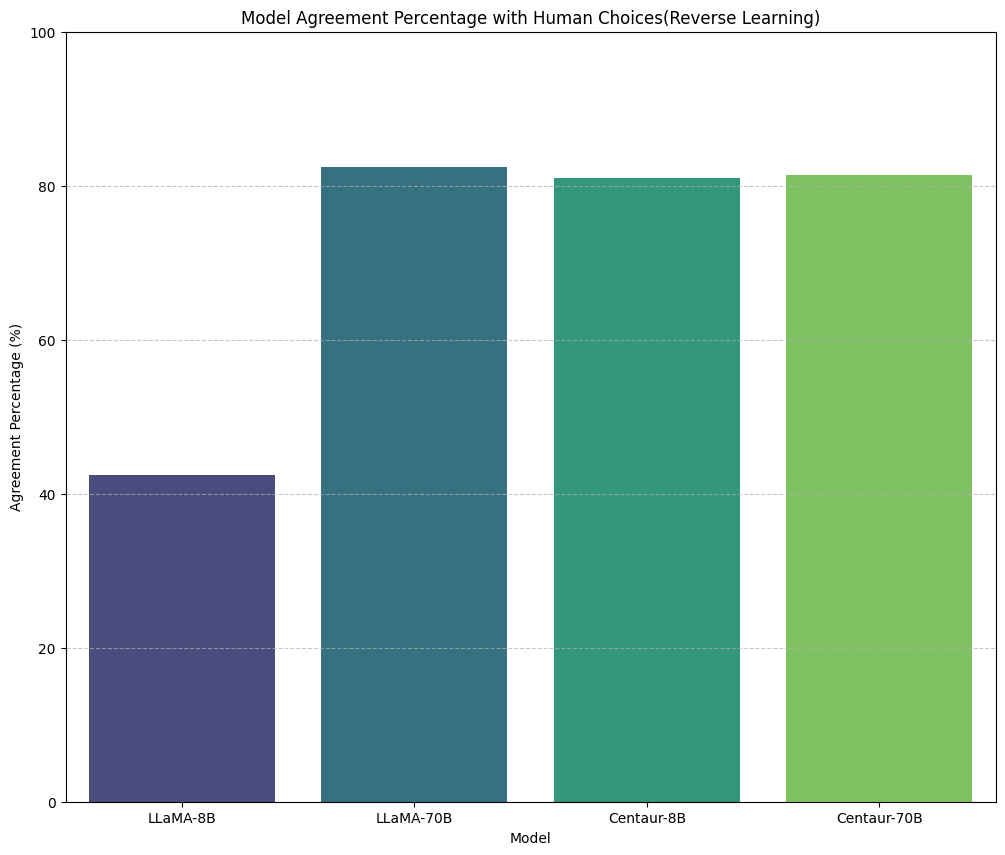

In [ ]:
# Create a dictionary to hold the agreement percentages
agreement_data = {
    'Model': ['LLaMA-8B', 'LLaMA-70B', 'Centaur-8B', 'Centaur-70B'],
    'Agreement Percentage': [
        agreement_percentage_8b_llama,
        agreement_percentage_70b_llama,
        agreement_percentage_8b_centaur,
        agreement_percentage_70b_centaur
    ]
}

# Create a pandas DataFrame from the data
agreement_df = pd.DataFrame(agreement_data)

# Create the bar plot
plt.figure(figsize=(12, 10))
sns.barplot(x='Model', y='Agreement Percentage', data=agreement_df, palette='viridis')
plt.title('Model Agreement Percentage with Human Choices(Reverse Learning)')
plt.ylabel('Agreement Percentage (%)')
plt.xlabel('Model')
plt.ylim(0, 100) # Set y-axis limit to 0-100%
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
horizon_8b_llama.rename(columns={'log_likelihood': 'log_likelihood_of_human_choice'}, inplace=True)
mean_ll_8b_llama, sem_ll_8b_llama = calculate_log_likelihood_stats(horizon_8b_llama)

In [ ]:
# prompt: load /content/drive/MyDrive/centaur/rw_model_metrics_horizon.json

import json

with open('/content/drive/MyDrive/centaur/reversal_learning/rw_model_metrics.json', 'r') as f:
    metrics_data = json.load(f)


In [ ]:
# prompt: load /content/drive/MyDrive/centaur/rw_model_metrics_horizon.json

import json

with open('/content/drive/MyDrive/centaur/reversal_learning/repetetive_metrics.json', 'r') as f:
    metrics_data_repetetive = json.load(f)


In [ ]:
metrics_data

{'validation_nll': 1361.0198180187288,
 'average_log_loss_per_trial': 0.42531869313085274}

In [ ]:
# prompt: extract average loss into mean_rw

# The negative log-likelihood is the loss.
# The average loss is the mean negative log-likelihood.
# The function calculate_log_likelihood_stats returns the mean log-likelihood.
# We need the negative of this mean for the average loss.
mean_rw = metrics_data.get('average_log_loss_per_trial', None)
mean_repetetive = metrics_data_repetetive.get('average_log_loss_per_trial', None)

In [ ]:
sem_rw=mean_rw/np.sqrt(len(horizon_70b))
sem_repetetive=mean_repetetive/np.sqrt(len(horizon_70b))

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

In [ ]:
plt.rcParams.update({
    'font.size': 22,        # everything (titles, labels, ticks, legend) gets bigger
    'axes.titlesize': 30,   # override just titles if you want
    'axes.labelsize': 28,   # axis labels
    'xtick.labelsize': 26,  # x-tick labels
    'ytick.labelsize': 28,  # y-tick labels
    'legend.fontsize': 22 #  # legend text
})
def plot_loglikelihood_bars(mu_centaur, sd_centaur,
                             mu_centaurB, sd_centaurB,
                             mu_llama, sd_llama,
                             mu_llamaB, sd_llamaB,
                             mu_rw, sd_rw,
                             mu_rep, sd_rep,
                             variant_labels = ['8B', '70B', '8B', '70B', 'RW','Rep'],
                             family_labels  = ['Centaur', 'LLama 3.1', 'Domain-Specific\nModel'],
                             colors = ['#E69F00', '#D55E00', '#56B4E9', '#0072B2', '#CC79A7'],
                             figsize=(12, 10)):
    """
    Clean and stylized grouped bar plot with NLL means and error bars.
    Includes two-level x-axis labels, grouped spacing, and a random guessing reference line.
    """
    # Values
    means = [-mu_centaur, -mu_centaurB, mu_llama, mu_llamaB, mu_rw,mu_rep]
    errs  = [sd_centaur, sd_centaurB, sd_llama, sd_llamaB, sd_rw,sd_rep]

    # Bar placement
    w = 0.50
    gap_in = 0.00
    gap_out = 0.1
    xpos = np.array([
        0,
        0 + w + gap_in,                             # Centaur-70B
        0 + 2*w + gap_in + gap_out,                 # LLaMA-8B
        0 + 3*w + 2*gap_in + gap_out,               # LLaMA-70B
        0 + 4*w + 2*gap_in + 2*gap_out,             # RW
        0 + 5*w + 3*gap_in + 2*gap_out              # Repetetive

    ])

    # Index groups for secondary x-axis labeling
    family_slices = [(0,1), (2,3), (4,5)]
    fig, ax = plt.subplots(figsize=figsize)

    # Bars
    bars=ax.bar(xpos, means, w,
           yerr=errs, capsize=5,
           color=colors, edgecolor='black', linewidth=0.3)
    for bar in bars:
      height = bar.get_height()
      ax.annotate(f'{height:.4f}',
                  xy=(bar.get_x() + bar.get_width() / 2, height),
                  xytext=(0, 3),
                  textcoords="offset points",
                  ha='center', va='bottom')


    # Chance line
    chance_nll = -np.log(0.5)
    ax.axhline(chance_nll, ls='--', c='grey', lw=1.2)
    ax.text(xpos[-2] + w*0.2, chance_nll, 'Random guessing',
            va='bottom', ha='left',fontsize=18)

    # X-axis: tick labels (1st tier)
    ax.set_xticks(xpos)
    ax.set_xticklabels(variant_labels, ha='center')

    # X-axis: group labels (2nd tier)
    for i, family_slice in enumerate(family_slices):
        if isinstance(family_slice, tuple):
            i0, i1 = family_slice
            center = (xpos[i0] + xpos[i1]) / 2
        else:
            center = xpos[family_slice]
        ax.text(center, -0.10, family_labels[i],
                ha='center', va='top',
                transform=ax.get_xaxis_transform(),
                fontsize=28
                )

    # Visual group dividers
    for i, family_slice in enumerate(family_slices[:-1]):
        if isinstance(family_slice, tuple):
            i0, i1 = family_slice
            ax.axvline(xpos[i1] + w/2 + gap_out/2, color='grey', lw=1)
        else:
            ax.axvline(xpos[family_slice] + w/2 + gap_out/2, color='grey', lw=1)

    # Axis labels and title
    ax.set_ylabel('Negative Log-Likelihood (NLL)')
    #ax.set_title('Predictive Performance')

    # Styling
    ax.spines[['top', 'right','left','bottom']].set_visible(True)
    ax.grid(False)
    ax.margins(x=0.04)
    # Hide all spines (top, bottom, left, right)
    for spine in ax.spines.values():
        spine.set_visible(True)

    # Get current axis limits (where bars are)
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    plt.tight_layout()
    return fig

In [ ]:
#human,centaur-7b,centaur-80b,llama-8b,llama-reason,rw,some other
colors_grouped= ['#44403B','#E69F00', '#D55E00', '#56B4E9', '#0072B2','#CC79A7','#009E73']

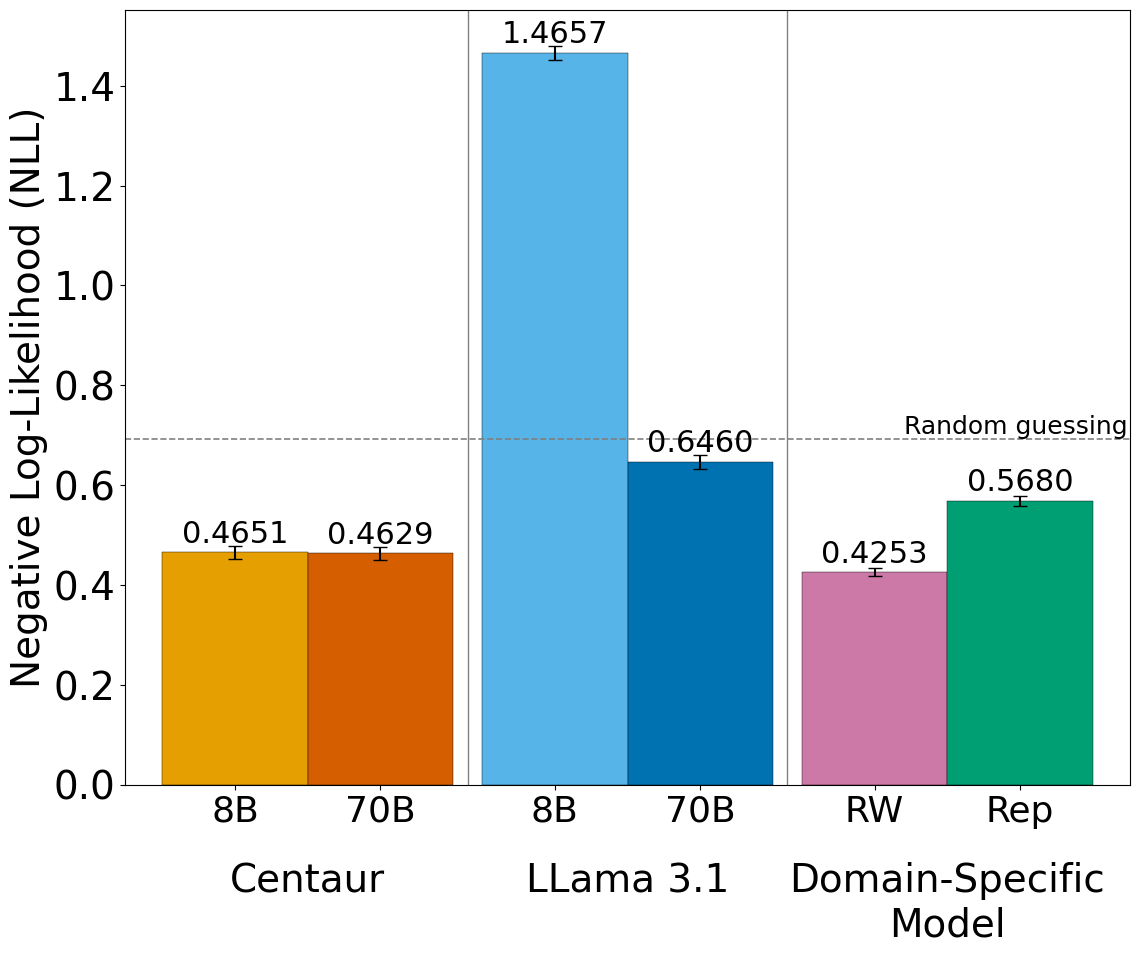

In [ ]:
nll_reverse_learning=plot_loglikelihood_bars(
    mu_centaur=mean_ll_8b,mu_centaurB=mean_ll_70b,mu_llama=mean_ll_8b_llama,mu_llamaB=mean_ll_70b_llama,mu_rw=mean_rw,mu_rep=mean_repetetive,
    sd_centaur=sem_ll_8b,sd_centaurB=sem_ll_70b,sd_llama=sem_ll_8b,sd_llamaB=sem_ll_70b,sd_rw=sem_rw,sd_rep=sem_repetetive,
                        colors=colors_grouped[1:]
                                             )

In [ ]:
nll_reverse_learning.savefig('/content/drive/MyDrive/centaur/figures/nll_reverse_learning.png', format='png', dpi=600, edgecolor='white', bbox_inches='tight', pad_inches=0.1)

In [ ]:
# prompt: save mean_ll_70b and sem_ll_70b in centaur folder as json

# Ensure the directory exists
output_dir = '/content/drive/MyDrive/centaur/'
os.makedirs(output_dir, exist_ok=True)

# Create a dictionary with the values
stats_to_save = {
    'mean_ll_70b': mean_ll_70b,
    'sem_ll_70b': sem_ll_70b,
    'mean_ll_8b': mean_ll_8b,
    'sem_ll_8b': sem_ll_8b,
    'mean_rw': mean_rw
}

# Define the output filename
output_filename = os.path.join(output_dir, 'eckstein_log_likelihood_stats.json')

# Save the dictionary to a JSON file
with open(output_filename, 'w') as f:
    json.dump(stats_to_save, f, indent=4)

print(f"Saved stats to {output_filename}")

Saved stats to /content/drive/MyDrive/centaur/eckstein_log_likelihood_stats.json


In [ ]:
stats_to_save

{'mean_ll_70b': np.float64(-0.4628825569152832),
 'sem_ll_70b': np.float64(0.01327880380279305),
 'mean_ll_8b': np.float64(-0.4650819206237793),
 'sem_ll_8b': np.float64(0.01327733224002282),
 'mean_rw': 0.42531869313085274}